# CRIANDO UMA REDE NEURAL PARA CLASSIFICAÇÃO DE IMAGENS (SEGMENTAÇÃO SEMÂNTICA) DE SATÉLITE

__Criação__: Sabrina Paes Leme (sabrina.correaufv.br) <br>
__Instituição__: Universidade Federal de Viçosa (UFV) <br>
__Descrição__: Este notebook é um tutorial de como criar uma rede neural convolucional em imagens de satélite ópticos e SAR para fins de uso e cobertura do solo (_land use and land cover_, LULC) usando o PyTorch.
__Dataset__: O dataset usado de referência é o [CerraData4mm](https://www.kaggle.com/datasets/cerranet/cerradata-4mm?resource=download)

## 1. ℹ️Sobre o Dataset

Este é um dataset criado a partir de imagens do sensor óptico Sentinel-2/MSI, com 10m a 60m de resolução espacial e o satélite de radar de abertura sintética (SAR) Sentinel-1 (até 30m). Os dois pertendem a Agência Espacial Europeia (ESA). As imagens são do ano de 2022, do  [Bico Do Papagaio](https://www.google.com/maps/place/Microrregi%C3%A3o+do+Bico+do+Papagaio,+TO/@-6.0847471,-49.3156601,9z/data=!3m1!4b1!4m6!3m5!1s0x92c54f1f80034233:0xf6f494459899f34e!8m2!3d-5.63885!4d-47.6627537!16s%2Fg%2F11j8kslnr2?entry=ttu&g_ep=EgoyMDI1MDUxMi4wIKXMDSoASAFQAw%3D%3D), no Cerrado Brasileiro, extremo norte do Estado do Tocantins.

### 1.1. Classes

O dataset é dividido entre as opções de 7 e 14 classes. Usaremos a opção de 7 classes neste projeto. As classes são:
* 0 - Pasture (Pastagem)
* 1 - Arboreal (Vegetação arbustiva)
* 2 - Agriculture (Agricultura)
* 3 - Mining (Mineração)
* 4 - Building (Área urbana, prédios)
* 5 - Water body (corpos d'água)
* 6 - Other uses (Outro usos)

### 1.2. Classificação

O dataset pode ser utilizado com os vértices (edge) e como a área, usaremos a área para segmentação semântica.

## 2. Sobre o tutorial

Este tutorial é subdivido em outros arquivos para entendermos melhor cada pedacinho do que está acontecendo em outros arquivos python também nessa pasta. Criei esse flucograma para melhorar a visuação do que está sendo feito.

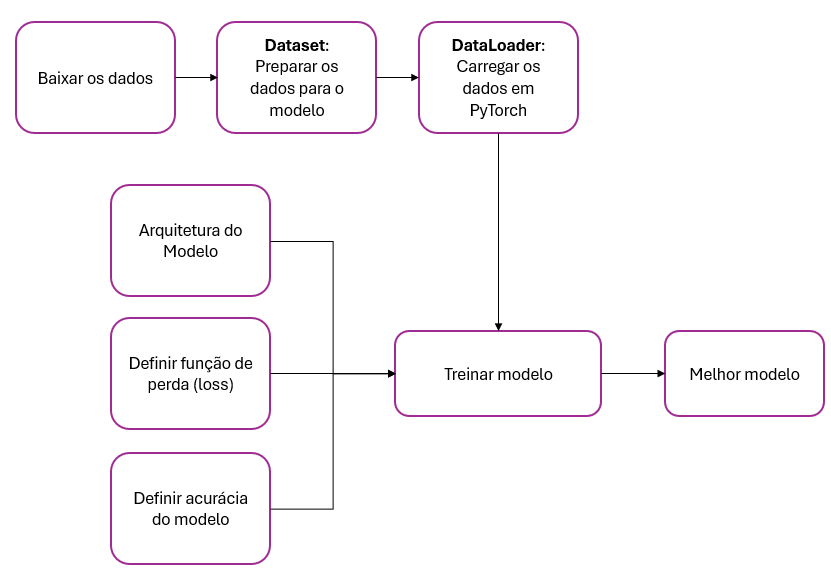

# 1. 📖 Bibliotecas

In [93]:
import os
import torch
import importlib
from torch.utils.data import random_split
from torch.utils.data import DataLoader
from torchinfo import summary
from torchview import draw_graph
import torch.multiprocessing as mp


import matplotlib.pyplot as plt
import numpy as np

In [28]:
# Dataset
import CerraDataDataset

# Arquitetura do modelo
from unet import UNet
import segformer

# 2. 🗂️ Importanto o dataset

A entrada de dados neste caso é apenas a pasta em que o dataset se encontra, pois ele já está bem subsividido entre máscara e amostras de treino/teste

In [7]:
caminho = "/mnt/d/Doutorado_UFV/DATASETS/cerradata4mm/cerradata_4mm"

Agora, é crucial definirmos se CUDA está disponível. O CUDA nos disponibilida a utilizar o GPU, que faz tudo rodar muito mais rápido.

In [8]:
# Testar se CUDA está disponível
cuda_available = torch.cuda.is_available()

device = torch.device("cuda" if cuda_available else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


Cria a instância do dataset com normalização '0a1' e transformação (aplicando transformações de dados) para aumentar a ariabilidade do dataset e melhorar o desempenho do modelo de aprendizado de máquina

In [9]:
importlib.reload(CerraDataDataset)

dataset = CerraDataDataset.CerraDataset(cam_dir=caminho, dispositivo=device, normalizacao='0a1', transformar=True)

# Verificar se o dataset foi carregado corretamente 
if dataset is not None:
    print("Dataset carregado com sucesso!")

Dataset carregado com sucesso!


Agora vamos dividir o dataset entre treinamento e teste numa proporção de 80%/20%

In [10]:
# Definir a proporção de treino e teste
razao  = 0.8  # 80% para treino
tam_treino = int(razao * len(dataset))
tam_teste = len(dataset) - tam_treino

# Dividir o dataset em treino e teste aleatoriamente
train_dataset, test_dataset = random_split(
    dataset,
    [tam_treino, tam_teste],
    generator=torch.Generator().manual_seed(42)  # Fixar a seed para reprodutibilidade
)

## 2.1. Criando os DataLoaders

Aqui, a gente já determina o tamanho do batch e número de processadores para trabalharmos.

Vamos aproveitar para determinar todos os parâmetros de entrada para ficarem todos organizadinhos e juntinhos.

In [90]:
batch_size     = 32        # Tamanho do lote
num_workers    = 0         # Número de workers para DataLoader
n_classes      = 7         # Número de classes
n_canais       = 12        # Número de canais
height, width  = 128 , 128 # Dimensões da imagem

epocas            = 1     # Número de épocas
taxa_aprendizagem = 0.001  # Taxa de aprendizado do modelos (learning rate)
taxa_decaimento   = 0.0001 # Taxa de decaimento do learning rate (weight decay)


Os DataLoaders vão ser as entradas dos dados para o nosso modelo. Eles ficam armazenados na GPU.

In [52]:
# Dataloaders para treino
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers
)

# Dataloader para teste
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # Não embaralhar os dados de teste
    num_workers=num_workers
)

## 2.2. Conferindo se o dataset está correto

In [53]:
# Cria uma função para plotar a imagem
def plot_imagem(dataset, idx):
    imagem, _ = dataset[idx]
    # Convertendo a imagem para numpy
    imagem = imagem.cpu().numpy()
    rgb_image = np.transpose(imagem[1:4], (1, 2, 0))  # Change to (H, W, C)
    plt.title(f"Imagem {idx}")
    plt.imshow(rgb_image)

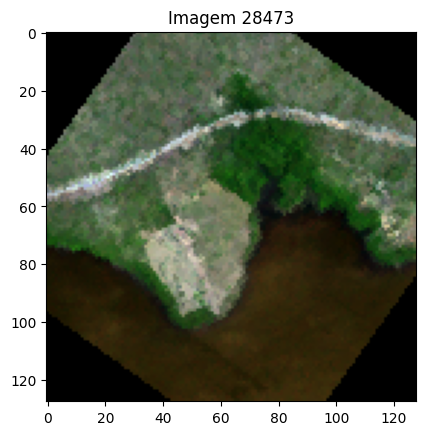

In [54]:
idx = np.random.randint(0, len(dataset)) # Pega um índice aleatório do dataset

# Plotar a imagem
plot_imagem(dataset, idx)
plt.show()

# 3. Arquitetura do modelo

O modelo foi todo definido no arquivo <code>segformer.py</code> e é chamado pelo <code>import segformer</code> lá em cima nas bibliotecas.

Aqui embaixo, nós vamos só chamar o modelo com uma entrada qualquer (dummy) para testar se o modelo tá abrindo certinho. Depois disso, a gente vai printar o resumo do modelo.

In [55]:
importlib.reload(segformer)

from segformer import SegFormerTransformer

Definindo o modelo (model) que vamos usar. Aqui a gente vai usar o <code> SegFormer</code> adaptado e vamos entrar com o número de bandas, número de classes e o tamanho da imagem.

In [ ]:
model = SegFormerTransformer(
    backbone_name = 'convnext_small',  # or 'convnext_small', 'coat_lite_tiny', etc.
    n_channels    = n_canais,
    n_classes     = n_classes,
    embed_dim     = height
).to(device)

Essa função vai salvar um fluxograma do modelo em PNG apenas. É totalmente opcional.

In [63]:
input_tensor = torch.randn(batch_size, n_canais, height, width)  # Example input
graph = draw_graph(model, input_data=input_tensor, depth=3)
graph.visual_graph.render("segformer_arch", format="png")

'segformer_arch.png'

Agora, nós estamos testando se o modelo roda bem pra uma situação qualquer ("dummy").

In [64]:
dummy_input = torch.randn(1, 12, 128, 128).to(device)  # Exemplo de entrada com batch size 1, 12 canais, 128x128
output = model(dummy_input)

print(f"Tamanho de entrada: {dummy_input.shape}")
print(f"Tamanho de saida  : {output.shape}") 

Tamanho de entrada: torch.Size([1, 12, 128, 128])
Tamanho de saida  : torch.Size([1, 7, 32, 32])


# 4. 🎯Configurações para treinamento

Toda a parte de treinamente e teste do modelo está em <code>treinamento.py</code>.

Alguns pontos importantes para se analizar em redes neurais:

1. __Checkpoints__
    * _Early Stop_: é parada antecipada. Se o modelo não estiver variando muito a cada tantas épocas (_patience_), então ele vai parar naquele modelo mesmo para não gastar mais processamento desnecessário.
    * _Save Best_: nem sempre o último modelo é o melhor. Às vezes ele está lá no meio das épocas, e a gente salva isso.
2. __Otimizador (_optimizer_)__
    * Os otimizadores são modelos cujo objetivo é minimizar a perda (_loss_) do modelo. São atualizados através dos cálculos de gradientes na _backpropagation_.
    * Geralmente usamos o Adam
3. __Critério (_criterion_)__
    * Os critérios são uma forma bonitinha de organizar as perdas. Para problemas de classificação, utilizados a _Cross Entropy_ (entropia cruzada).

In [ ]:
import funcao_treino 
importlib.reload(funcao_treino)

<module 'treinamento' from '/home/sabrina/phd/projectsUFV/CNN_CV/treinamento.py'>

### 4.1. Otimizador
Vamos primeiro definir o otimizador.

Ele usa a taxa de aprendizagem (_learning rate_) e a taxa de decaimento dos pesos (_weight decay_) para controlar como os gradientes vão ser calculados.

In [72]:
otimizador = torch.optim.Adam(model.parameters(),
                              lr=taxa_aprendizagem,
                              weight_decay=taxa_decaimento)

### 4.2. Critérios

Agora, para os critérios, vamos considerar a _Cross Entropy_ e a _Dice Loss_ combinadas.

In [ ]:
# Definindo as perdas que vamos usar
ce_loss   = torch.nn.CrossEntropyLoss()
dice_loss = funcao_treino.DiceLoss()

# Aqui estamos juntando as duas perdas (CrossEntropy e DiceLoss) 
def perdas_combinadas(logits, targets):
    """ArithmeticErrortic mean of the two losses."""

    return (ce_loss(logits, targets) + dice_loss(logits, targets))/2



# 5. 📊Treinamento

Ufa! Agora comtudo ajustado podemos treinar nosso modelo! Vamos recaptular os hiperparâmetros do nosso modelo, pra depois usar eles:

In [91]:
dicto_treinamento = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "epocas": epocas,
    "taxa_aprendizagem": taxa_aprendizagem,
    "taxa_decaimento": taxa_decaimento, 
    "device": device,
    "n_classes": n_classes,
    "n_canais": n_canais,
    "height": height,
    "width": width,

}

dicto_treinamento


{'batch_size': 32,
 'num_workers': 0,
 'epocas': 1,
 'taxa_aprendizagem': 0.001,
 'taxa_decaimento': 0.0001,
 'device': device(type='cuda'),
 'n_classes': 7,
 'n_canais': 12,
 'height': 128,
 'width': 128}

Agora, vamos juntar os DataLoaders num dicionário só para a entrada do modelo

In [79]:
dataloaders = {
    "train": train_loader,
    "test": test_loader
}

In [ ]:
if __name__ == '__main__':
    mp.set_start_method('spawn')

    modelo_treinamento = funcao_treino.treino(
    model=model,
    dataloaders=dataloaders,
    optimizer=otimizador,
    criterion=perdas_combinadas,
    n_epochs=epocas,
    device=device,
    patience=5,
    use_amp=False,
    verbose=True,
    )

RuntimeError: context has already been set